# Diagrama P-v modelado con PRSV para Deueterio (D₂)
---

In [ ]:
! pip install thermo
! pip install chemicals

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import thermo
import chemicals
from scipy.integrate import quad

CAS_NUMBER = chemicals.search_chemical('deuterium').CASs
Pc =  chemicals.Pc(CAS_NUMBER) # [Pa]
Tc = chemicals.Tc(CAS_NUMBER) # [K]
Tt = chemicals.Tt(CAS_NUMBER)
k1 = 0 #fuente que estudio el uso de diferentes ecuaciones de estado para el hidrogeno, asigno esto, y el hidrogeno similar al deuterio
w = chemicals.omega(CAS_NUMBER)
R = 8.3145 # [J/molK]

* PSRV for P


In [2]:
def alfaF(T, Tc, w, k1):
    m = 0.378893 + 1.4897153*w -0.171384*w**2 + 0.0196554*w**3
    return (1+m*(1-(T/Tc)**0.5) + k1*(1-(T/Tc))*(0.7-(T/Tc)))**2

def PRSV_P(v, alfa, T, R, Tc, Pc):
    ac = 0.45724*((R*Tc**2)/Pc)
    b = 0.07780*R*Tc/Pc
    return (R*T/(v-b)) - ((ac*alfa)/(v*(v+b) + b*(v-b)))

def PRSV_V(alfa, T, R, Tc, P, Pc):
    ac = 0.45724*(R*Tc**2/Pc)
    b = 0.07780*R*Tc/Pc
    a = ac*alfa
    C3 = 1.0
    C2 = b - (R * T) / P
    C1 = (a / P) - 3 * (b**2) - (2 * b * R * T) / P
    C0 = (b**3) + (b**2 * R * T) / P - (a * b) / P    
    roots = np.roots([C3, C2, C1, C0])
    
    real_roots = np.real(roots[np.isclose(np.imag(roots), 0, atol=1e-10)])
    real_roots = real_roots[0.1 > real_roots > b]
    return real_roots


* Criterio de Maxwell para el Equilibrio


In [37]:
def maxwellAreas(vv, vl, P, T, R, Tc, Pc, alfa):
    return P*(vv - vl) - quad(PRSV_P,  vl, vv, args=(alfa, T, R, Tc, Pc))[0]

* Calculo de fugacidad para PRSV
 

In [32]:
def func(v,T, alfa, ac, b, R):
    return v*((-R*T)/(v-b)**2 - (ac*alfa*(2*v + 2*b)/((v**2+v*b+b*v-b**2)**2)))


def f(alfa, T, R, v):
    vinf = np.max(PRSV_V(alfa, T, R, Tc, 5, Pc))
    ac = 0.45724*(8.3145*Tc**2.5/Pc)
    b = 0.07780*R*Tc/Pc
    return np.exp((quad(func, vinf, v, args=(T, alfa, ac, b, R))/(R*T))[0]) * (Pc/100)


* PRSV for V and Execution

In [35]:
from scipy.optimize import brentq

T = 20 #K

alfa = alfaF(T, Tc, w, k1)

def maxwellAreas(P, T, R, Tc, Pc, alfa):
    roots = PRSV_V(alfa, T, R, Tc, P, Pc)
    if len(roots) < 3:
        return 1.0 
    return P*(np.max(roots) - np.min(roots)) - quad(PRSV_P,  np.min(roots), np.max(roots), args=(alfa, T, R, Tc, Pc))[0]

try:
    # Find the exact P where fugacity difference is zero
    Psat = brentq(maxwellAreas, 0.001, Pc, args=(T, R, Tc, Pc, alfa))
    # Now you have the EXACT pressure to draw your horizontal line!
    roots_at_sat = PRSV_V(alfa, T, R, Tc, Psat, Pc)
    v_liquid = np.min(roots_at_sat)
    v_vapor = np.max(roots_at_sat)
    
    # Plot the horizontal tie-line
    plt.plot([v_liquid, v_vapor], [Psat/1e6, Psat/1e6], 'k--') 
except Exception as e: 
    print(e)
    pass # Temperature might be above critical or search range



f(a) and f(b) must have different signs


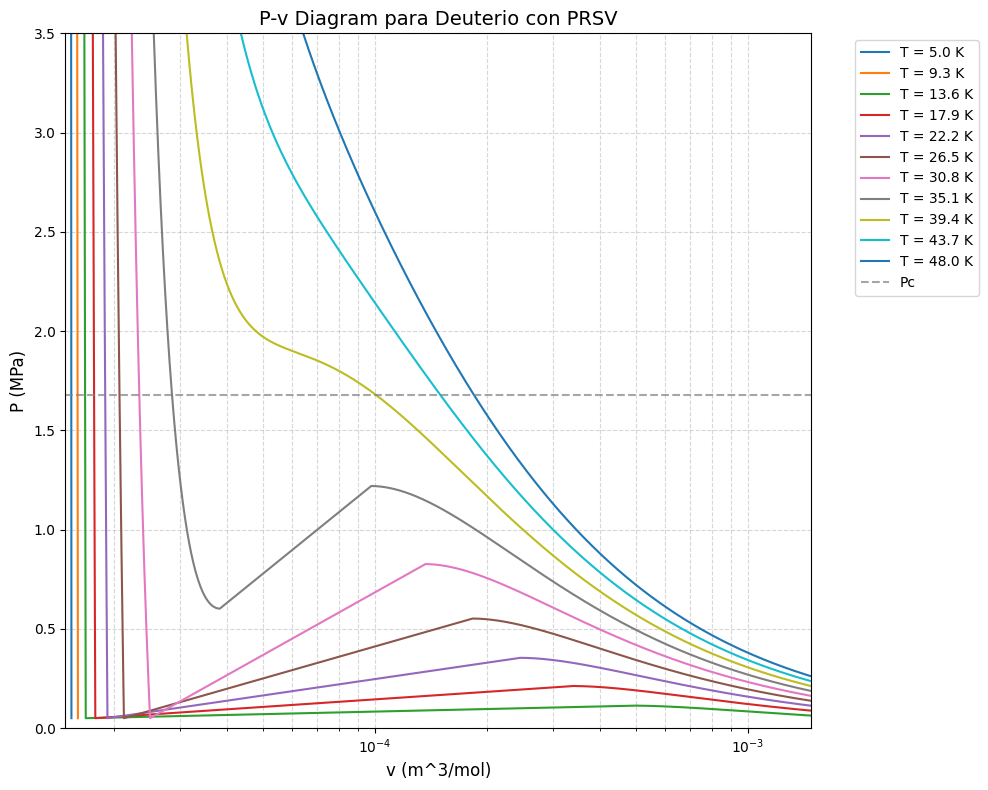

In [38]:
ac = 0.457235 * (R**2)* (Tc**2) / Pc # como en el articulo de PRSV
b = 0.077796 * R* Tc / Pc

temperatures = np.linspace(5, 48, 11) #[K]

pressures = np.linspace(0.05e6, 3.5e6, 100000) #[Pa]

plt.figure(figsize=(10, 8))

for T in temperatures:
    Tr = T / Tc
    alfa = alfaF(T, Tc, w, k1)
    a = ac * alfa
    
    v_plot = []
    p_plot = []
    
    for P in pressures:
        C3 = 1.0
        C2 = b - (R * T) / P
        C1 = (a / P) - 3 * (b**2) - (2 * b * R * T) / P
        C0 = (b**3) + (b**2 * R * T) / P - (a * b) / P
        
        roots = np.roots([C3, C2, C1, C0])
        
        real_roots = np.real(roots[np.isclose(np.imag(roots), 0, atol=1e-10)])
        real_roots = real_roots[real_roots > b]

        if len(real_roots) > 1:
            if maxwellAreas(np.max(real_roots),np.min(real_roots), P, T,R, Tc, Pc, alfa):
                v_plot.append(np.max(real_roots))
                v_plot.append(np.min(real_roots))
                p_plot.append(P / 1e6) 
                p_plot.append(P / 1e6) 
            else:
                p_plot.append(P / 1e6) 
                fv = f(alfa, T, R, np.max(real_roots))
                fl = f(alfa, T, R, np.min(real_roots))
                if fv < fl:
                    v_plot.append(np.max(real_roots))
                elif fl < fv:
                    v_plot.append(np.min(real_roots)) 
        else: 
            v_plot.append(real_roots[0])
            p_plot.append(P / 1e6) 

    v_plot = np.array(v_plot)
    p_plot = np.array(p_plot)
    
    sort_indices = np.argsort(v_plot)
    v_plot_sorted = v_plot[sort_indices]
    p_plot_sorted = p_plot[sort_indices]
    
    if np.isclose(T, Tc, atol=1.0):
        plt.plot(v_plot_sorted, p_plot_sorted, label=f'T = {T:.1f} K (Near Critical)', linewidth=2.5, color='black')
    else:
        plt.plot(v_plot_sorted, p_plot_sorted, label=f'T = {T:.1f} K')

plt.title('P-v Diagram para Deuterio con PRSV', fontsize=14)
plt.xlabel('v (m^3/mol)', fontsize=12)
plt.ylabel('P (MPa)', fontsize=12)

plt.ylim(0, 3.5)
plt.xlim(b, b * 100)    
plt.xscale('log')

plt.axhline(Pc / 1e6, color='gray', linestyle='--', alpha=0.7, label='Pc')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()

plt.show()


# Morante's Version

In [18]:
from scipy.optimize import fsolve, minimize_scalar
b = 0.077796 * R* Tc / Pc

def encontrar_raices(P, T):
    v_range = np.linspace(b * 1.01, 0.01, 1000)
    f_vals = PRSV_P(v_range, alfa, T, R, Tc, Pc) - P
    signos = np.sign(f_vals)
    cruces = np.where(np.diff(signos))[0]

    raices = []
    for i in cruces:
        v1, v2 = v_range[i], v_range[i + 1]
        try:
            root = fsolve(lambda v: PRSV_P(v, alfa, T, R, Tc, Pc) - P, x0=(v1 + v2) / 2)[0]
            if b < root < 0.01:
                raices.append(root)
        except:
            continue
    raices = np.unique(np.round(raices, 8))
    return np.sort(raices)

# Función de área para criterio de Maxwell
def maxwell_area(P, T):
    try:
        roots = encontrar_raices(P, T)
        if len(roots) < 2:
            return np.inf
        v_l, v_v = roots[0], roots[-1]
        v_range = np.linspace(v_l, v_v, 300)
        area = np.trapz([PRSV_P(v, T) - P for v in v_range], x=v_range)
        return abs(area)
    except:
        return np.inf


def PsatF(T):
    result = minimize_scalar(maxwell_area, args=(T,), bounds=(1e4, Pc), method='bounded')
    if result.success:
        Psat = result.x
        roots = encontrar_raices(Psat, T)
        if len(roots) >= 2:
            return Psat, roots[0], roots[-1]
    return None, None, None



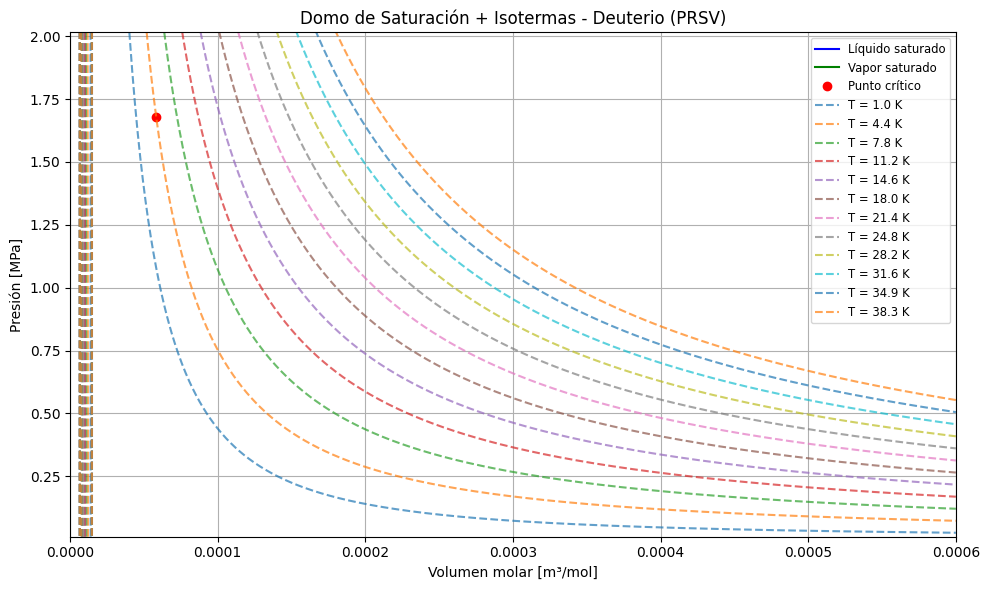

In [31]:
T_values = np.linspace(1, Tc, 500)
vl_list = []
vv_list = []
Psat_list = []

for T in T_values:
    alfa = alfaF(T, Tc, w, k1)
    Psat, vl, vv = PsatF(T)
    if Psat is not None:
        vl_list.append(vl)
        vv_list.append(vv)
        Psat_list.append(Psat / 1e6)



vc = chemicals.Vc(CAS_NUMBER)  # m³/mol -> Esta raroooo -_-. Pero no esta mal. Y se basa en datos experimentales
Pc_MPa = Pc / 1e6
vl_list.append(vc)
vv_list.append(vc)
Psat_list.append(Pc_MPa)

plt.figure(figsize=(10, 6))
plt.plot(vl_list, Psat_list, 'b-', label='Líquido saturado')
plt.plot(vv_list, Psat_list, 'g-', label='Vapor saturado')
plt.plot([vc], [Pc_MPa], 'ro', label='Punto crítico')

T_isotermas = np.linspace(1, Tc, 12)
v_vals = np.linspace(0.0000001, 0.0006, 1000)

for T_iso in T_isotermas:
    T_iso = float(T_iso)
    alfa = alfaF(T_iso, Tc, w, k1)
    P_vals = [PRSV_P(v, alfa, T_iso, R, Tc, Pc) for v in v_vals]
    P_vals = np.array(P_vals) / 1e6  # Convertir a MPa
    # P_vals[P_vals > 10] = np.nan     # Recorte para evitar picos no físicos
    plt.plot(v_vals, P_vals, '--', alpha=0.7, label=f'T = {T_iso:.1f} K')

plt.xlabel("Volumen molar [m³/mol]")
plt.ylabel("Presión [MPa]")
plt.title("Domo de Saturación + Isotermas - Deuterio (PRSV)")
plt.ylim(0.01, 1.2*Pc/1e6)
plt.xlim(0, 0.0006)
plt.grid(True)
plt.legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.show()



# Prem 2.0 Version

* Subiendo los datos y librerias relevantes

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from thermo.eos import PRSV
import chemicals
from scipy.integrate import quad
from scipy.optimize import fsolve, minimize_scalar

CAS_NUMBER = chemicals.search_chemical('deuterium').CASs
Pc =  chemicals.Pc(CAS_NUMBER) # [Pa]
Tc = chemicals.Tc(CAS_NUMBER) # [K]
Tt = chemicals.Tt(CAS_NUMBER) #[K]
Pt = chemicals.Pt(CAS_NUMBER) # [Pa]
k1 = 0 #fuente que estudio el uso de diferentes ecuaciones de estado para el hidrogeno, asigno esto, y el hidrogeno similar al deuterio
w = chemicals.omega(CAS_NUMBER)
R = 8.3145 # [J/molK]
b = 0.07780*R*Tc/Pc
ac = 0.45724*(R*Tc**2/Pc)

*  Planteando las funciones a utilizar

In [ ]:
alfaF = lambda w, T, Tc, k1: (1+(0.378893 + 1.4897153*w -0.171384*w**2 + 0.0196554*w**3)*(1-(T/Tc)**0.5) + k1*(1-(T/Tc))*(0.7-(T/Tc)))**2

def PRSV_P(v, T):
    alfa = alfaF(w, T, Tc, k1)
    return (R*T/(v-b)) - ((ac*alfa)/(v*(v+b) + b*(v-b)))

# def PRSV_V(T, P):
#     alfa = alfaF(w, T, Tc, k1)
#     a = alfa*ac
#     C3 = 1.0
#     C2 = b - (R * T) / P
#     C1 = (a / P) - 3 * (b**2) - (2 * b * R * T) / P
#     C0 = (b**3) + (b**2 * R * T) / P - (a * b) / P    
#     roots = np.roots([C3, C2, C1, C0])

#     real_roots = np.real(roots[np.abs(np.imag(roots)) < 1e-5]) 
#     real_roots = real_roots[real_roots > b]
#     return real_roots

def PRSV_V(T, P):
    alfa = alfaF(w, T, Tc, k1)
    a = alfa * ac
    
    # Calculate dimensionless A and B
    A = (a * P) / (R * T)**2
    B = (b * P) / (R * T)
    
    # Coefficients for Z^3 + c2*Z^2 + c1*Z + c0 = 0
    c2 = -(1 - B)
    c1 = A - 2*B - 3*B**2
    c0 = -(A*B - B**2 - B**3)
    
    roots = np.roots([1.0, c2, c1, c0])
    
    # Filter real roots and convert Z back to V (V = ZRT/P)
    real_Z = np.real(roots[np.abs(np.imag(roots)) < 1e-6])
    real_V = real_Z * R * T / P
    
    # Ensure V > b (physical constraint)
    return np.sort(real_V[real_V > b])




1.8009434121964796e-05 905.6901872800188


* Encontrando la presion de saturacion

In [ ]:
def maxwell_area(P, T):
    roots = PRSV_V(T, P)
    # roots = encontrar_raices(P, T) 
    # print('P:' , P, ',   roots: ', roots)
    if len(roots) < 2:
        return 1e14*(P/Pc) #Esto genera un gradiente que ayuda a que el optimizador 
                           #(minimize scalar) encuentre la respuesta de manera mas clara. Donde, si P > Pc, 
                           # por alli no es
    else:
        vv = np.max(roots)
        vl = np.min(roots)
        v_i = np.linspace(vl, vv, 1000)

        return abs(P*(vv - vl) - np.trapz([PRSV_P(v, T) for v in v_i], x=v_i))


# def encontrar_raices(P, T):
#     v_range = np.linspace(b * 1.01, 0.01, 1000)
#     f_vals = PRSV_P(v_range, T) - P
#     signos = np.sign(f_vals)
#     cruces = np.where(np.diff(signos))[0]

#     raices = []
#     for i in cruces:
#         v1, v2 = v_range[i], v_range[i + 1]
#         try:
#             root = fsolve(lambda v: PRSV_P(v, T) - P, x0=(v1 + v2) / 2)[0]
#             if b < root < 0.01:
#                 raices.append(root)
#         except:
#             continue
#     raices = np.unique(np.round(raices, 8))
#     return np.sort(raices)

# def encontrar_saturacion(T):
#     result = minimize_scalar(maxwell_area, args=(T,), bounds=(Pt, Pc), method='bounded')
#     if result.success:
#         Psat = result.x
#         # roots = encontrar_raices(Psat, T)
#         eos = PRSV(Tc, Pc, w, T = T, P = Psat)
#         vv, vl = eos.V_g, eos.V_l
        
#     return Psat, vl, vv


# def encontrar_raices(P, T):
#     v_range = np.linspace(b * 1.01, 0.01, 1000)
#     f_vals = PRSV_P(v_range, T) - P
#     signos = np.sign(f_vals)
#     cruces = np.where(np.diff(signos))[0]
#     raices = []
#     for i in cruces:
#         v1, v2 = v_range[i], v_range[i + 1]
#         try:
#             root = fsolve(lambda v: PRSV_P(v, T) - P, x0=(v1 + v2) / 2)[0]
# #             if b < root < 0.01:
#                 raices.append(root)
#         except:
#             continue
#     raices = np.unique(np.round(raices, 8))
#     return np.sort(raices)



def encontrar_saturacion(T):
    result = minimize_scalar(maxwell_area, args=(T,), bounds=(Pt, Pc), method='bounded')
    if result.success:
        Psat = result.x
        # roots = encontrar_raices(Psat, T)
        roots = PRSV_V(T,Psat)
        if len(roots) >= 2:
            return Psat, np.min(roots), np.max(roots)
    return None, None, None

* Creando las graficas


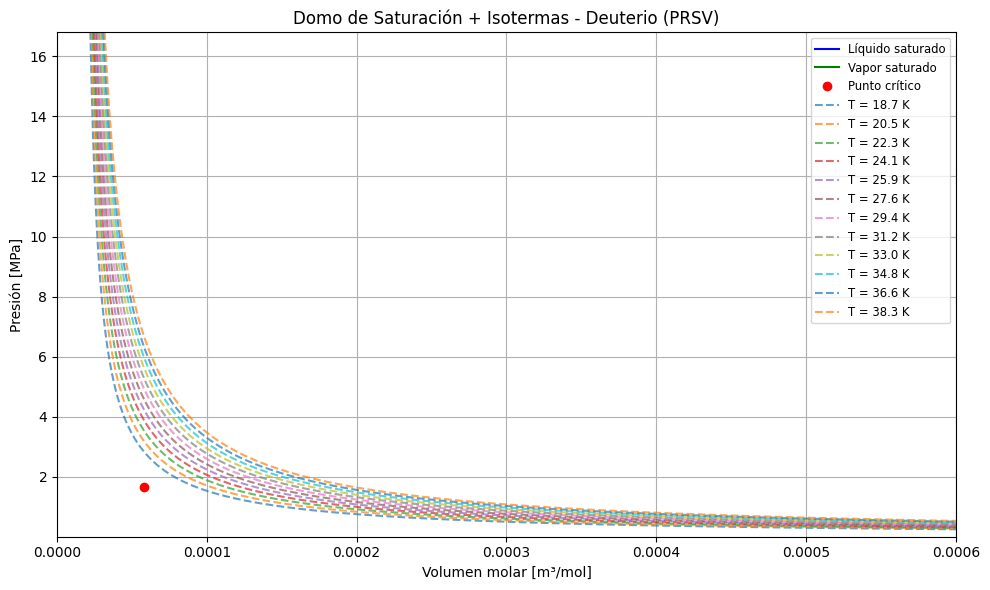

In [54]:
T_values = np.linspace(Tt, Tc-1, 500)
vl_list = []
vv_list = []
Psat_list = []

for T in T_values:
    Psat, vl, vv = encontrar_saturacion(T)
    if Psat is not None:
        vl_list.append(vl)
        vv_list.append(vv)
        Psat_list.append(Psat / 1e6)

# Añadir punto crítico calculado con la ecuación de Redlich-Kwong
vc = chemicals.Vc(CAS_NUMBER)
Pc_MPa = Pc / 1e6
vl_list.append(vc)
vv_list.append(vc)
Psat_list.append(Pc_MPa)

# Crear figura y graficar el domo
plt.figure(figsize=(10, 6))
plt.plot(vl_list, Psat_list, 'b-', label='Líquido saturado')
plt.plot(vv_list, Psat_list, 'g-', label='Vapor saturado')
plt.plot([vc], [Pc_MPa], 'ro', label='Punto crítico')
#no estan apareciendo entonces a.k.a no hay


# Graficar 10 isotermas
T_isotermas = np.linspace(Tt, Tc, 12)
# v_vals = np.linspace(0.0000001, 0.0006, 1000)


# --- Plotting Adjustment ---
# Increase the v_vals range to see the gas phase
v_vals = np.logspace(np.log10(b*1.01), np.log10(0.01), 1000)

for T_iso in T_isotermas:
    P_vals = [PRSV_P(v, T_iso) for v in v_vals]
    P_vals = np.array(P_vals) / 1e6  # Convertir a MPa
    P_vals[P_vals > 60] = np.nan     # Recorte para evitar picos no físicos
    plt.plot(v_vals, P_vals, '--', alpha=0.7, label=f'T = {T_iso:.1f} K')

# Finalizar gráfico
plt.xlabel("Volumen molar [m³/mol]")
plt.ylabel("Presión [MPa]")
plt.title("Domo de Saturación + Isotermas - Deuterio (PRSV)")
plt.ylim(0.01, 10*Pc/1e6)
plt.xlim(0, 0.0006)
plt.grid(True)
plt.legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.show()


# Literal solo reemplazo de lo de Morante -_-

C:\Users\premz\AppData\Local\Temp\ipykernel_57472\170304840.py:34: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(lambda v: PRSV_P(v, T) - P, x0=(v1 + v2) / 2)[0]


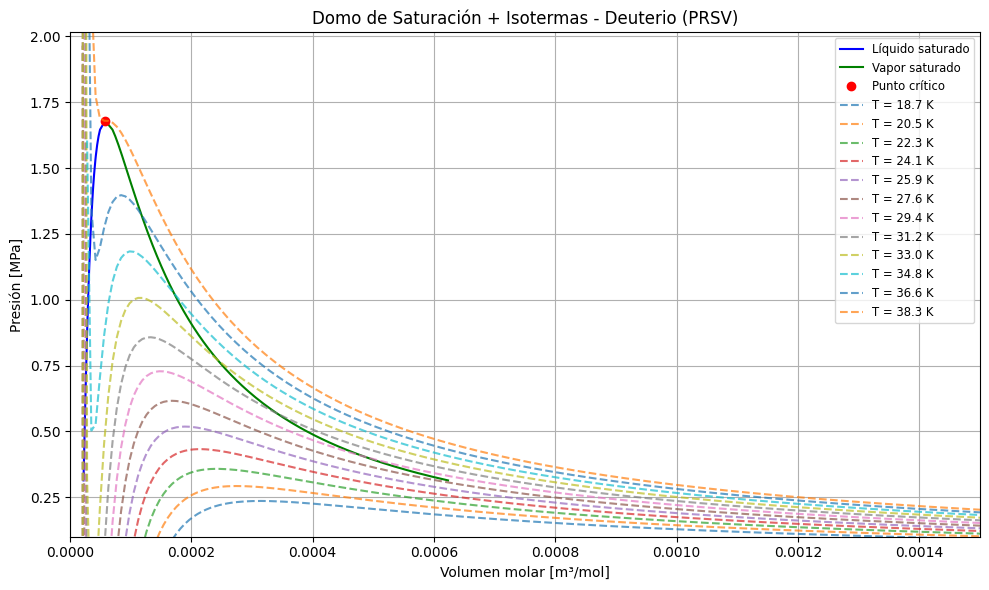

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve, minimize_scalar
import chemicals

# Constantes para acetona 
R = 8.314  # J/mol·K
CAS_NUMBER = chemicals.search_chemical('deuterium').CASs
Tc = chemicals.Tc(CAS_NUMBER)  # K
Pc = chemicals.Pc(CAS_NUMBER) # Pa
Tt = chemicals.Tt(CAS_NUMBER)
Pt = chemicals.Pt(CAS_NUMBER)
w = chemicals.omega(CAS_NUMBER)

#Parametros para PRSV
ac = 0.45724 * R**2 * Tc**2 / Pc
b = 0.07780 * R * Tc / Pc
m = 0.378893 + 1.4897153*w - 0.171384*w**2 + 0.0196554*w**3

def PRSV_P(v, T):
    return (R * T) / (v - b) - (((1+m*(1-(T/Tc)**0.5)))**2)*ac / (v*(v+b) + b*(v-b))

# Función para encontrar raíces reales positivas
def encontrar_raices(P, T):
    v_range = np.linspace(b * 1.01, 1, 1000)
    f_vals = PRSV_P(v_range, T) - P  
    signos = np.sign(f_vals)
    cruces = np.where(np.diff(signos))[0]

    raices = []
    for i in cruces:
        v1, v2 = v_range[i], v_range[i + 1]
        try:
            root = fsolve(lambda v: PRSV_P(v, T) - P, x0= np.min(v1, v2))[0]
            if b < root < 0.01:
                raices.append(root)
        except:
            continue
    raices = np.unique(np.round(raices, 8))
    return np.sort(raices)

# Función de área para criterio de Maxwell
def maxwell_area(P, T):
    try:
        roots = encontrar_raices(P, T)
        if len(roots) < 2:
            return np.inf
        v_l, v_v = roots[0], roots[-1]
        v_range = np.linspace(v_l, v_v, 300)
        area = np.trapz([PRSV_P(v, T) - P for v in v_range], x=v_range)
        return abs(area)
    except:
        return np.inf

# Encontrar presión de saturación
def encontrar_saturacion(T):
    result = minimize_scalar(maxwell_area, args=(T,), bounds=(1e4, Pc), method='bounded')
    if result.success:
        Psat = result.x
        roots = encontrar_raices(Psat, T)
        if len(roots) >= 2:
            return Psat, roots[0], roots[-1]
    return None, None, None

# Generar temperaturas y construir domo
T_values = np.linspace(Tt, Tc, 500)
vl_list = []
vv_list = []
Psat_list = []

for T in T_values:
    Psat, vl, vv = encontrar_saturacion(T)
    if Psat is not None:
        vl_list.append(vl)
        vv_list.append(vv)
        Psat_list.append(Psat / 1e6)

# Añadir punto crítico calculado con la ecuación de Redlich-Kwong
vc = chemicals.Vc(CAS_NUMBER)  # m³/mol
Pc_MPa = Pc / 1e6
vl_list.append(vc)
vv_list.append(vc)
Psat_list.append(Pc_MPa)

# Crear figura y graficar el domo
plt.figure(figsize=(10, 6))
plt.plot(vl_list, Psat_list, 'b-', label='Líquido saturado')
plt.plot(vv_list, Psat_list, 'g-', label='Vapor saturado')
plt.plot([vc], [Pc_MPa], 'ro', label='Punto crítico')

# Graficar 10 isotermas
T_isotermas = np.linspace(Tt, Tc, 12)
v_vals = np.linspace(0.0000001, 0.007, 1000)

for T_iso in T_isotermas:
    P_vals = [PRSV_P(v, T_iso) for v in v_vals]
    P_vals = np.array(P_vals) / 1e6  # Convertir a MPa
    P_vals[P_vals > 10] = np.nan     # Recorte para evitar picos no físicos
    plt.plot(v_vals, P_vals, '--', alpha=0.7, label=f'T = {T_iso:.1f} K')

# Finalizar gráfico
plt.xlabel("Volumen molar [m³/mol]")
plt.ylabel("Presión [MPa]")
plt.title("Domo de Saturación + Isotermas - Deuterio (PRSV)")
plt.ylim(0.1, 1.2*Pc/1e6)
plt.xlim(0, 0.0015)
plt.grid(True)
plt.legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.show()



# Le pedi a gemini que lo hiciera

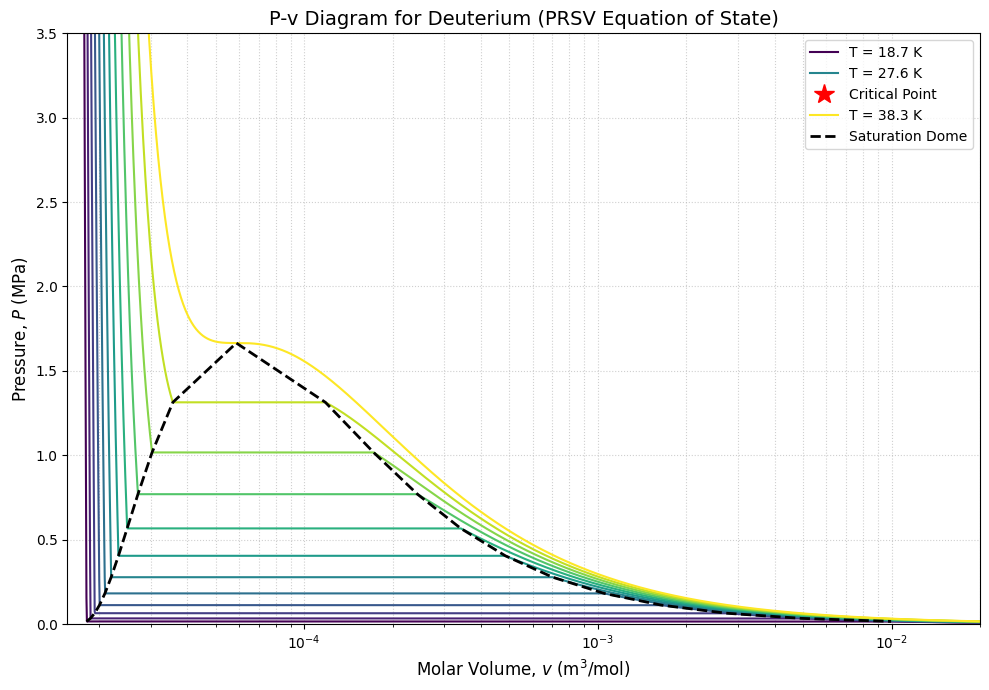

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# --- Constants for Deuterium (D2) ---
R = 8.31446261815324  # Universal gas constant [J/(mol*K)]
Tc = 38.3             # Critical Temperature [K]
Pc = 1.665e6          # Critical Pressure [Pa]
omega = -0.140        # Acentric factor (Quantum corrected for D2)
Tt = 18.73            # Triple point temperature [K]

# PRSV parameters
# kappa_1 is typically a fitted parameter; 0.0 is used for fluids lacking specific PRSV tables
kappa_1 = 0.0  
kappa_0 = 0.378893 + 1.4897153*omega - 0.17131848*(omega**2) + 0.0196554*(omega**3)

# Core Peng-Robinson parameters
a_c = 0.457235 * (R**2 * Tc**2) / Pc
b = 0.077796 * R * Tc / Pc
Zc = 0.3074  # Typical critical compressibility for PR EOS
vc = Zc * R * Tc / Pc

def get_alpha(T):
    """Calculate the PRSV alpha function."""
    Tr = T / Tc
    kappa = kappa_0 + kappa_1 * (1.0 + np.sqrt(Tr)) * (0.7 - Tr)
    return (1.0 + kappa * (1.0 - np.sqrt(Tr)))**2

def get_spinodal(T, a_T):
    """Finds the local minimum and maximum pressures (spinodals) analytically."""
    # Derivative of PR EOS w.r.t volume equals 0 expands to a 4th order polynomial
    coeffs = [
        R * T,
        4 * b * R * T - 2 * a_T,
        2 * (b**2) * R * T + 2 * a_T * b,
        -4 * (b**3) * R * T + 2 * a_T * (b**2),
        (b**4) * R * T - 2 * a_T * (b**3)
    ]
    roots = np.roots(coeffs)
    real_roots = np.real(roots[np.isclose(np.imag(roots), 0)])
    real_roots = real_roots[real_roots > b] # Volume must be greater than b
    
    if len(real_roots) >= 2:
        real_roots = np.sort(real_roots)
        v1, v2 = real_roots[0], real_roots[1]
        P1 = R * T / (v1 - b) - a_T / (v1**2 + 2 * b * v1 - b**2)
        P2 = R * T / (v2 - b) - a_T / (v2**2 + 2 * b * v2 - b**2)
        P_min, P_max = min(P1, P2), max(P1, P2)
        return max(1.0, P_min), P_max  # Pressure must be > 0
    return None, None

def maxwell_residual(P, T, a_T):
    """Calculates the area difference for the Maxwell construction."""
    A = a_T * P / (R**2 * T**2)
    B = b * P / (R * T)
    
    # Coefficients for Z^3 + pZ^2 + qZ + r = 0
    roots = np.roots([1.0, B - 1.0, A - 2.0*B - 3.0*B**2, B**3 + B**2 - A*B])
    real_roots = np.real(roots[np.isclose(np.imag(roots), 0)])
    
    # Must have 3 real roots for a phase split
    if len(real_roots) < 3:
        return 1e9  
    
    real_roots = np.sort(real_roots)
    Z_l, Z_g = real_roots[0], real_roots[-1]
    v_l, v_g = Z_l * R * T / P, Z_g * R * T / P
    
    # Analytical integral of the PR equation
    R1 = b * (1.0 - np.sqrt(2.0))
    R2 = b * (1.0 + np.sqrt(2.0))
    
    term1 = R * T * np.log((v_g - b) / (v_l - b))
    term2 = (a_T / (2.0 * np.sqrt(2.0) * b)) * np.log(
        ((v_g + R1) * (v_l + R2)) / ((v_g + R2) * (v_l + R1))
    )
    
    # Integral minus the rectangular area P * (v_g - v_l)
    return term1 - term2 - P * (v_g - v_l)

def get_roots(P, T, a_T):
    """Retrieve liquid and vapor volumes for a converged Pressure."""
    A = a_T * P / (R**2 * T**2)
    B = b * P / (R * T)
    roots = np.roots([1.0, B - 1.0, A - 2.0*B - 3.0*B**2, B**3 + B**2 - A*B])
    real_roots = np.sort(np.real(roots[np.isclose(np.imag(roots), 0)]))
    return real_roots[0] * R * T / P, real_roots[-1] * R * T / P

# --- Main Computation and Plotting ---
plt.figure(figsize=(10, 7))

# Generate plotting grid (logarithmic due to vast density differences)
v_grid = np.logspace(np.log10(1.05 * b), np.log10(0.02), 2000)

temperatures = np.linspace(Tt, Tc, 12)
v_l_sat_list, v_g_sat_list, P_sat_list = [], [], []

# Use custom colormap for isotherms
colors = plt.cm.viridis(np.linspace(0, 1, len(temperatures)))

for i, T in enumerate(temperatures):
    a_T = a_c * get_alpha(T)
    P_iso = R * T / (v_grid - b) - a_T / (v_grid**2 + 2 * b * v_grid - b**2)
    
    if T < Tc:
        P_min, P_max = get_spinodal(T, a_T)
        
        # Pad bounds slightly to guarantee exactly 3 roots inside the optimization space
        P_lower = P_min + 1e-4 * (P_max - P_min)
        P_upper = P_max - 1e-4 * (P_max - P_min)
        
        # Solve Maxwell equal area via bounded minimization
        res = minimize_scalar(
            lambda P: abs(maxwell_residual(P, T, a_T)), 
            bounds=(P_lower, P_upper), 
            method='bounded'
        )
        P_sat = res.x
        v_l, v_g = get_roots(P_sat, T, a_T)
        
        v_l_sat_list.append(v_l)
        v_g_sat_list.append(v_g)
        P_sat_list.append(P_sat)
        
        # Flatten the isotherm within the saturation dome
        P_plot = np.where((v_grid >= v_l) & (v_grid <= v_g), P_sat, P_iso)
    else:
        # Critical isotherm
        P_plot = P_iso
        plt.plot(vc, Pc, 'r*', markersize=15, label='Critical Point', zorder=5)

    # Plot each isotherm
    plt.semilogx(v_grid, P_plot / 1e6, color=colors[i], 
                 label=f'T = {T:.1f} K' if i in [0, 5, 11] else "")

# Construct and plot the saturation dome
v_dome = v_l_sat_list + [vc] + v_g_sat_list[::-1]
P_dome = np.array(P_sat_list + [Pc] + P_sat_list[::-1])
plt.semilogx(v_dome, P_dome / 1e6, 'k--', linewidth=2, label='Saturation Dome', zorder=4)

# Formatting
plt.title('P-v Diagram for Deuterium (PRSV Equation of State)', fontsize=14)
plt.xlabel('Molar Volume, $v$ (m$^3$/mol)', fontsize=12)
plt.ylabel('Pressure, $P$ (MPa)', fontsize=12)
plt.xlim(v_grid.min(), v_grid.max())
plt.ylim(0, 3.5) # Bounded cleanly around the critical pressure of 1.665 MPa
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()